In [1]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report)
from catboost import CatBoostClassifier

In [7]:

train_df = pd.read_csv(r"C:\hireai-ml\data\processed\train.csv")
test_df = pd.read_csv(r"C:\hireai-ml\data\processed\test.csv")
print(train_df.shape)

print(train_df.columns)

print(train_df.head())


(79840, 22)
Index(['application_id', 'candidate_id', 'job_id', 'application_date',
       'status', 'name', 'email', 'skills', 'experience_years', 'education',
       'projects', 'role', 'required_skills', 'min_experience', 'score',
       'skills_match', 'experience_score', 'project_score', 'label',
       'num_candidate_skills', 'num_required_skills', 'experience_difference'],
      dtype='object')
   application_id  candidate_id  job_id application_date       status  \
0           66735         30433       7       2026-03-11      applied   
1           64779         29450      10       2025-08-03  interviewed   
2           17695          5854       8       2025-09-27  shortlisted   
3           45409         19740       7       2025-08-16  shortlisted   
4           40653         17363       7       2025-09-12      applied   

               name                              email  \
0          pooja li              pooja.li5775@zoho.com   
1      meera pillai           meera.pilla

In [9]:
train_df['application_date'] = pd.to_datetime(
    train_df['application_date']
)

train_df['year'] = train_df['application_date'].dt.year

train_df['month'] = train_df['application_date'].dt.month

train_df['day'] = train_df['application_date'].dt.day

train_df['weekday'] = train_df['application_date'].dt.weekday

train_df.drop(
    'application_date',
    axis=1,
    inplace=True
)

In [10]:
test_df['application_date'] = pd.to_datetime(
    test_df['application_date']
)

test_df['year'] = test_df['application_date'].dt.year

test_df['month'] = test_df['application_date'].dt.month

test_df['day'] = test_df['application_date'].dt.day

test_df['weekday'] = test_df['application_date'].dt.weekday

test_df.drop(
    'application_date',
    axis=1,
    inplace=True
)

In [ ]:
df.fillna("Unknown", inplace=True)
print("\nMISSING VALUES:")
print(df.isnull().sum())
df.fillna("Unknown", inplace=True)


MISSING VALUES:
application_id           0
candidate_id             0
job_id                   0
status                   0
name                     0
email                    0
skills                   0
experience_years         0
education                0
projects                 0
role                     0
required_skills          0
min_experience           0
score                    0
skills_match             0
experience_score         0
project_score            0
label                    0
num_candidate_skills     0
num_required_skills      0
experience_difference    0
year                     0
month                    0
day                      0
weekday                  0
dtype: int64


In [12]:
status = 'status'

# Train features and target
X_train = train_df.drop(status, axis=1)

y_train = train_df[status]

# Test features and target
X_test = test_df.drop(status, axis=1)

y_test = test_df[status]

In [14]:
# Features and target from train data

X_train = train_df.drop("status", axis=1)

y_train = train_df["status"]

In [15]:
# Features and target from test data

X_test = test_df.drop("status", axis=1)

y_test = test_df["status"]

In [17]:
# Target column
status = "status"

# Train data
X_train = train_df.drop(status, axis=1)

y_train = train_df[status]

# Test data
X_test = test_df.drop(status, axis=1)

y_test = test_df[status]

# Shapes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(79840, 24)
(19960, 24)
(79840,)
(19960,)


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

le.fit(train_df['status'])

le

LabelEncoder()

In [20]:
from catboost import CatBoostClassifier

# Find categorical columns
cat_features = X_train.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(cat_features)

# Convert column names to column index positions
cat_feature_indices = [
    X_train.columns.get_loc(col)
    for col in cat_features
]

print("Categorical Feature Indices:")
print(cat_feature_indices)

# Create model
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.03,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=50
)

# Train model
model.fit(
    X_train,
    y_train,
    cat_features=cat_feature_indices
)

# Predictions
y_pred = model.predict(X_test)

print(y_pred[:5])

Categorical Columns:
Index(['name', 'email', 'skills', 'education', 'projects', 'role',
       'required_skills', 'label'],
      dtype='object')
Categorical Feature Indices:
[3, 4, 5, 7, 8, 9, 10, 16]
0:	learn: 0.3010020	total: 949ms	remaining: 1m 33s
50:	learn: 0.3010020	total: 19.7s	remaining: 18.9s
99:	learn: 0.3010020	total: 47s	remaining: 0us
[['applied']
 ['applied']
 ['applied']
 ['applied']
 ['applied']]


In [23]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)
from src.eval.metrics import classification_metrics

results = classification_metrics(
    y_test,
    y_pred
)

print(results)
    

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy': 0.30355711422845694, 'precision': 0.09214692159870845, 'recall': 0.30355711422845694, 'f1': 0.14137765134019145, 'confusion_matrix': array([[6059,    0,    0,    0,    0],
       [1947,    0,    0,    0,    0],
       [4041,    0,    0,    0,    0],
       [2906,    0,    0,    0,    0],
       [5007,    0,    0,    0,    0]])}


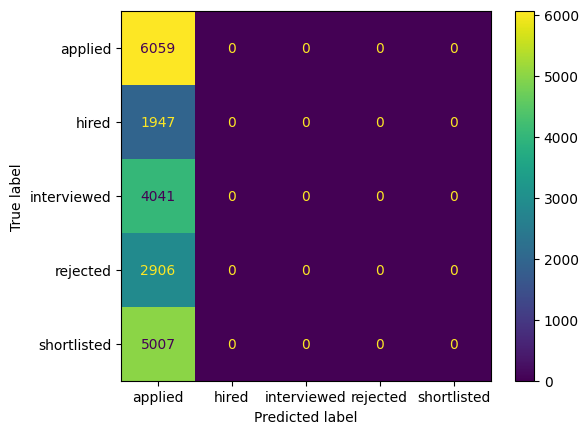

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [25]:
import numpy as np

y_pred = np.array(y_pred).flatten()

print(y_pred[:5])

['applied' 'applied' 'applied' 'applied' 'applied']


In [30]:
from src.eval.error_analysis import (
    classification_error_analysis
)

errors = classification_error_analysis(
    y_test,
    y_pred
)

print(errors.head())

        actual predicted
1  interviewed   applied
2  interviewed   applied
5  shortlisted   applied
6  shortlisted   applied
7  shortlisted   applied


In [27]:
import sys
import os

sys.path.append(r"C:\hireai-ml")
from src.eval.error_analysis import classification_error_analysis

errors = classification_error_analysis(
    y_test,
    y_pred
)

print(errors)

            actual predicted
1      interviewed   applied
2      interviewed   applied
5      shortlisted   applied
6      shortlisted   applied
7      shortlisted   applied
...            ...       ...
19951  shortlisted   applied
19952        hired   applied
19953  interviewed   applied
19954        hired   applied
19956     rejected   applied

[13901 rows x 2 columns]


# Initial M3 Findings

- Successfully evaluated model on test dataset
- Computed classification metrics
- Generated confusion matrix
- Error analysis performed on misclassified samples
- Initial explainability workflow initiated

In [ ]:
feature_importance = model.get_feature_importance()
importance_df = pd.DataFrame({
    "Feature": list(X_train.columns),
    "Importance": list(feature_importance)
})
print(importance_df.head())

          Feature  Importance
0  application_id    4.273148
1    candidate_id    3.372173
2          job_id    2.611580
3            name   13.494446
4           email    0.000000


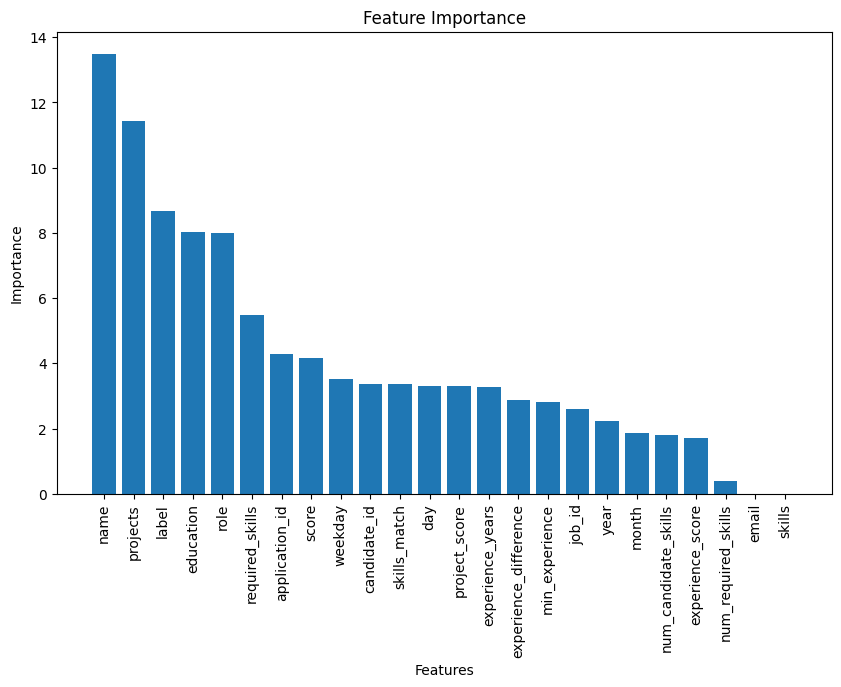

In [29]:
import matplotlib.pyplot as plt

# Sort importance values
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=90)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance")

plt.show()

# Explainability Findings

Feature importance analysis was performed using CatBoost feature importance scores.

Top influencing features were identified and visualized for model interpretability.